z# 📌 Extracción

In [1]:
import pandas as pd

In [2]:
data = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [3]:
df = pd.read_json(data)
df.head(5)


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [4]:
df.to_json('Data.json')

# 🔧 Transformación

In [5]:
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

In [6]:
df_normalizado = pd.concat([
    df[['customerID', 'Churn']],
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)

df_normalizado.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [7]:
df_normalizado.info()

<class 'pandas.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   str    
 1   Churn             7267 non-null   str    
 2   gender            7267 non-null   str    
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   str    
 5   Dependents        7267 non-null   str    
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   str    
 8   MultipleLines     7267 non-null   str    
 9   InternetService   7267 non-null   str    
 10  OnlineSecurity    7267 non-null   str    
 11  OnlineBackup      7267 non-null   str    
 12  DeviceProtection  7267 non-null   str    
 13  TechSupport       7267 non-null   str    
 14  StreamingTV       7267 non-null   str    
 15  StreamingMovies   7267 non-null   str    
 16  Contract          7267 non-null   str    
 17  Paperl

In [8]:
df_normalizado.dtypes

customerID              str
Churn                   str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
Charges.Monthly     float64
Charges.Total           str
dtype: object

## Verificando si hay datos repetidos :)

In [9]:
df_normalizado.duplicated().sum()

np.int64(0)

In [10]:
df_normalizado.duplicated(subset=['customerID']).sum()

np.int64(0)

In [11]:
df_normalizado.isnull().sum()

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64

In [12]:
# Filtramos solo las columnas de texto
columnas_texto = df_normalizado.select_dtypes(include=['object', 'str']).columns

# Iteramos y mostramos los valores únicos de cada una
for col in columnas_texto:
    print(f"--- {col} ---")
    print(df_normalizado[col].unique())
    print()

--- customerID ---
<StringArray>
['0002-ORFBO', '0003-MKNFE', '0004-TLHLJ', '0011-IGKFF', '0013-EXCHZ',
 '0013-MHZWF', '0013-SMEOE', '0014-BMAQU', '0015-UOCOJ', '0016-QLJIS',
 ...
 '9975-SKRNR', '9978-HYCIN', '9979-RGMZT', '9985-MWVIX', '9986-BONCE',
 '9987-LUTYD', '9992-RRAMN', '9992-UJOEL', '9993-LHIEB', '9995-HOTOH']
Length: 7267, dtype: str

--- Churn ---
<StringArray>
['No', 'Yes', '']
Length: 3, dtype: str

--- gender ---
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

--- Partner ---
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

--- Dependents ---
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

--- PhoneService ---
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

--- MultipleLines ---
<StringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str

--- InternetService ---
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

--- OnlineSecurity ---
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

--- OnlineBackup ---
<S

In [13]:
import numpy as np

# 1. Convertimos los espacios vacíos '' en nulos en todo el dataframe
df_normalizado.replace('', np.nan, inplace=True)
df_normalizado.replace(' ', np.nan, inplace=True) # Por si acaso hay espacios en blanco

# 2. Convertimos Charges.Total a formato numérico
df_normalizado['Charges.Total'] = pd.to_numeric(df_normalizado['Charges.Total'], errors='coerce')


df_normalizado.isnull().sum()

customerID            0
Churn               224
gender                0
SeniorCitizen         0
Partner               0
Dependents            0
tenure                0
PhoneService          0
MultipleLines         0
InternetService       0
OnlineSecurity        0
OnlineBackup          0
DeviceProtection      0
TechSupport           0
StreamingTV           0
StreamingMovies       0
Contract              0
PaperlessBilling      0
PaymentMethod         0
Charges.Monthly       0
Charges.Total        11
dtype: int64

In [14]:
# 1. Eliminamos cualquier fila que tenga al menos un valor nulo (NaN)
df_normalizado.dropna(inplace=True)

# 2. Reiniciamos el índice para que la numeración de las filas vuelva a ser continua
df_normalizado.reset_index(drop=True, inplace=True)

# 3. Verificamos cuántas filas nos quedaron al final para nuestro análisis
f"Total de filas listas para analizar: {df_normalizado.shape[0]}"

'Total de filas listas para analizar: 7032'

In [15]:
df_normalizado

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.60,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.90,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,No,Female,0,No,No,13,Yes,No,DSL,...,No,No,Yes,No,No,One year,No,Mailed check,55.15,742.90
7028,9992-RRAMN,Yes,Male,0,Yes,No,22,Yes,Yes,Fiber optic,...,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,85.10,1873.70
7029,9992-UJOEL,No,Male,0,No,No,2,Yes,No,DSL,...,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,50.30,92.75
7030,9993-LHIEB,No,Male,0,Yes,Yes,67,Yes,No,DSL,...,No,Yes,Yes,No,Yes,Two year,No,Mailed check,67.85,4627.65


In [16]:
# Creamos la nueva columna dividiendo el cargo mensual entre 30 días
df_normalizado['Cuentas_Diarias'] = (df_normalizado['Charges.Monthly'] / 30).round(2)

# Damos un vistazo para comprobar que se creó correctamente
df_normalizado[['customerID', 'Charges.Monthly', 'Cuentas_Diarias']].head()

,customerID,Charges.Monthly,Cuentas_Diarias
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80


In [17]:
# 1. Diccionario para traducir las columnas al español
traduccion_columnas = {
    'customerID': 'ID_Cliente',
    'Churn': 'Evasion',
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'Pareja',
    'Dependents': 'Dependientes',
    'tenure': 'Meses_Contrato',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Lineas_Multiples',
    'InternetService': 'Servicio_Internet',
    'OnlineSecurity': 'Seguridad_Online',
    'OnlineBackup': 'Respaldo_Online',
    'DeviceProtection': 'Proteccion_Dispositivo',
    'TechSupport': 'Soporte_Tecnico',
    'StreamingTV': 'Streaming_TV',
    'StreamingMovies': 'Streaming_Peliculas',
    'Contract': 'Contrato',
    'PaperlessBilling': 'Facturacion_Electronica',
    'PaymentMethod': 'Metodo_Pago',
    'Charges.Monthly': 'Cargo_Mensual',
    'Charges.Total': 'Cargo_Total'
}

# Aplicamos la traducción al DataFrame
df_normalizado.rename(columns=traduccion_columnas, inplace=True)

# 2. Convertir 'Yes' y 'No' a 1 y 0
mapeo_binario = {'Yes': 1, 'No': 0}

# Seleccionamos las columnas que solo tienen Yes/No
columnas_binarias = ['Evasion', 'Pareja', 'Dependientes','Servicio_Telefonico', 'Facturacion_Electronica']

# Aplicamos el mapeo a cada columna
for col in columnas_binarias:
    df_normalizado[col] = df_normalizado[col].map(mapeo_binario)

# Vemos los primeros registros para confirmar los cambios
df_normalizado.head()

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [18]:
# Diccionario con las traducciones de los valores internos
traduccion_valores = {
    # Género
    'Female': 'Femenino',
    'Male': 'Masculino',

    # Contratos
    'Month-to-month': 'Mes a mes',
    'One year': 'Un año',
    'Two year': 'Dos años',

    # Métodos de pago
    'Electronic check': 'Cheque electrónico',
    'Mailed check': 'Cheque por correo',
    'Bank transfer (automatic)': 'Transferencia bancaria (automática)',
    'Credit card (automatic)': 'Tarjeta de crédito (automática)',

    # Servicios de Internet y variaciones
    'Fiber optic': 'Fibra óptica',
    'No internet service': 'Sin servicio de internet',
    'No phone service': 'Sin servicio telefónico',

    # Para los "Yes" que quedaron en las columnas de servicios adicionales
    'Yes': 'Sí'
}

# Aplicamos la traducción a todas las celdas del DataFrame
df_normalizado.replace(traduccion_valores, inplace=True)

df_normalizado

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Facturacion_Electronica,Metodo_Pago,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
0,0002-ORFBO,0,Femenino,0,1,1,9,1,No,DSL,...,No,Sí,Sí,No,Un año,1,Cheque por correo,65.60,593.30,2.19
1,0003-MKNFE,0,Masculino,0,0,0,9,1,Sí,DSL,...,No,No,No,Sí,Mes a mes,0,Cheque por correo,59.90,542.40,2.00
2,0004-TLHLJ,1,Masculino,0,0,0,4,1,No,Fibra óptica,...,Sí,No,No,No,Mes a mes,1,Cheque electrónico,73.90,280.85,2.46
3,0011-IGKFF,1,Masculino,1,1,0,13,1,No,Fibra óptica,...,Sí,No,Sí,Sí,Mes a mes,1,Cheque electrónico,98.00,1237.85,3.27
4,0013-EXCHZ,1,Femenino,1,1,0,3,1,No,Fibra óptica,...,No,Sí,Sí,No,Mes a mes,1,Cheque por correo,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,9987-LUTYD,0,Femenino,0,0,0,13,1,No,DSL,...,No,Sí,No,No,Un año,0,Cheque por correo,55.15,742.90,1.84
7028,9992-RRAMN,1,Masculino,0,1,0,22,1,Sí,Fibra óptica,...,No,No,No,Sí,Mes a mes,1,Cheque electrónico,85.10,1873.70,2.84
7029,9992-UJOEL,0,Masculino,0,0,0,2,1,No,DSL,...,No,No,No,No,Mes a mes,1,Cheque por correo,50.30,92.75,1.68
7030,9993-LHIEB,0,Masculino,0,1,1,67,1,No,DSL,...,Sí,Sí,No,Sí,Dos años,0,Cheque por correo,67.85,4627.65,2.26


# 📊 Carga y análisis

In [19]:
# Resumen estadístico de las variables numéricas
df_normalizado.describe()

,Evasion,Adulto_Mayor,Pareja,Dependientes,Meses_Contrato,Servicio_Telefonico,Facturacion_Electronica,Cargo_Mensual,Cargo_Total,Cuentas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,2.159891
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,1.002955
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.610000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,1.187500
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.340000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,2.992500
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


In [20]:
# Resumen estadístico de las variables categóricas (textos)
df_normalizado.describe(include=['object', 'category', 'str'])

,ID_Cliente,Genero,Lineas_Multiples,Servicio_Internet,Seguridad_Online,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Contrato,Metodo_Pago
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,3,3,3,3,3,3,3,3,3,4
top,0002-ORFBO,Masculino,No,Fibra óptica,No,No,No,No,No,No,Mes a mes,Cheque electrónico
freq,1,3549,3385,3096,3497,3087,3094,3472,2809,2781,3875,2365


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

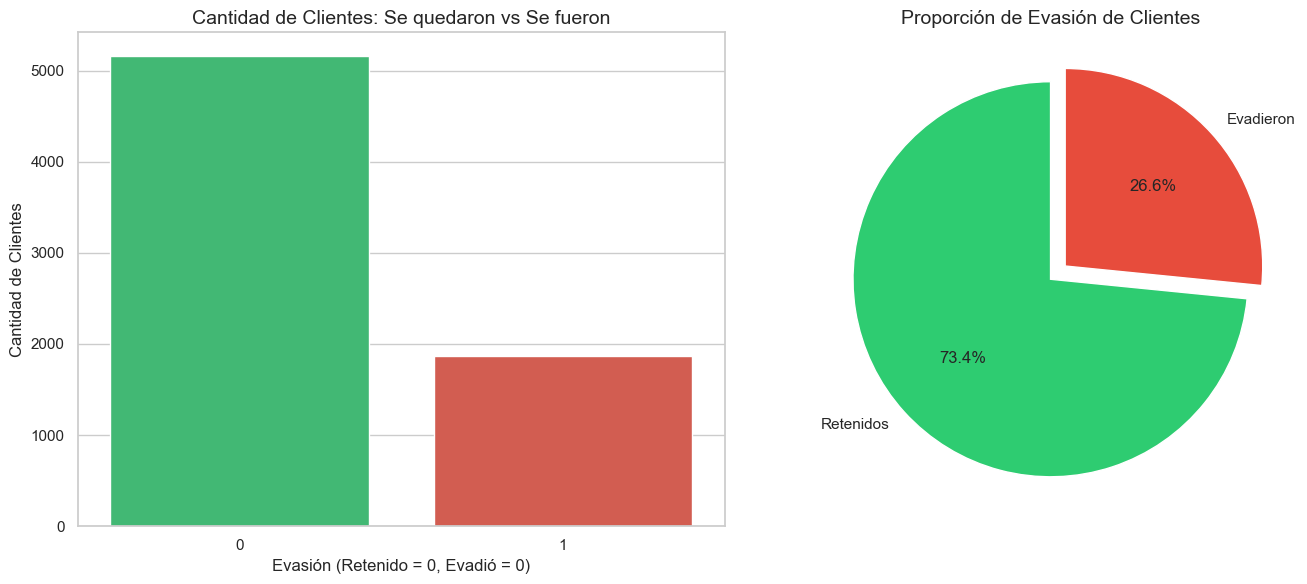

In [22]:
# Configuramos un estilo para los gráficos
sns.set_theme(style="whitegrid")

# Creamos un "lienzo" con dos espacios (1 fila, 2 columnas)
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de Barras
# Usamos colores verde para los que se quedan, rojo para los que se van
sns.countplot(data=df_normalizado, x='Evasion', ax=ax[0], hue='Evasion', palette=['#2ecc71', '#e74c3c'], legend=False)
ax[0].set_title('Cantidad de Clientes: Se quedaron vs Se fueron', fontsize=14)
ax[0].set_xlabel('Evasión (Retenido = 0, Evadió = 0)', fontsize=12)
ax[0].set_ylabel('Cantidad de Clientes', fontsize=12)

# 2. Gráfico de Pastel (Proporciones)

# Contamos cuántos hay de cada uno
evasion_counts = df_normalizado['Evasion'].value_counts()

# Dibujamos el pastel
ax[1].pie(evasion_counts,
          labels=['Retenidos', 'Evadieron'],
          autopct='%1.1f%%',
          colors=['#2ecc71', '#e74c3c'],
          startangle=90,
          explode=(0, 0.1))
ax[1].set_title('Proporción de Evasión de Clientes', fontsize=14)

# Ajustamos y mostramos el gráfico
plt.tight_layout()
plt.show()

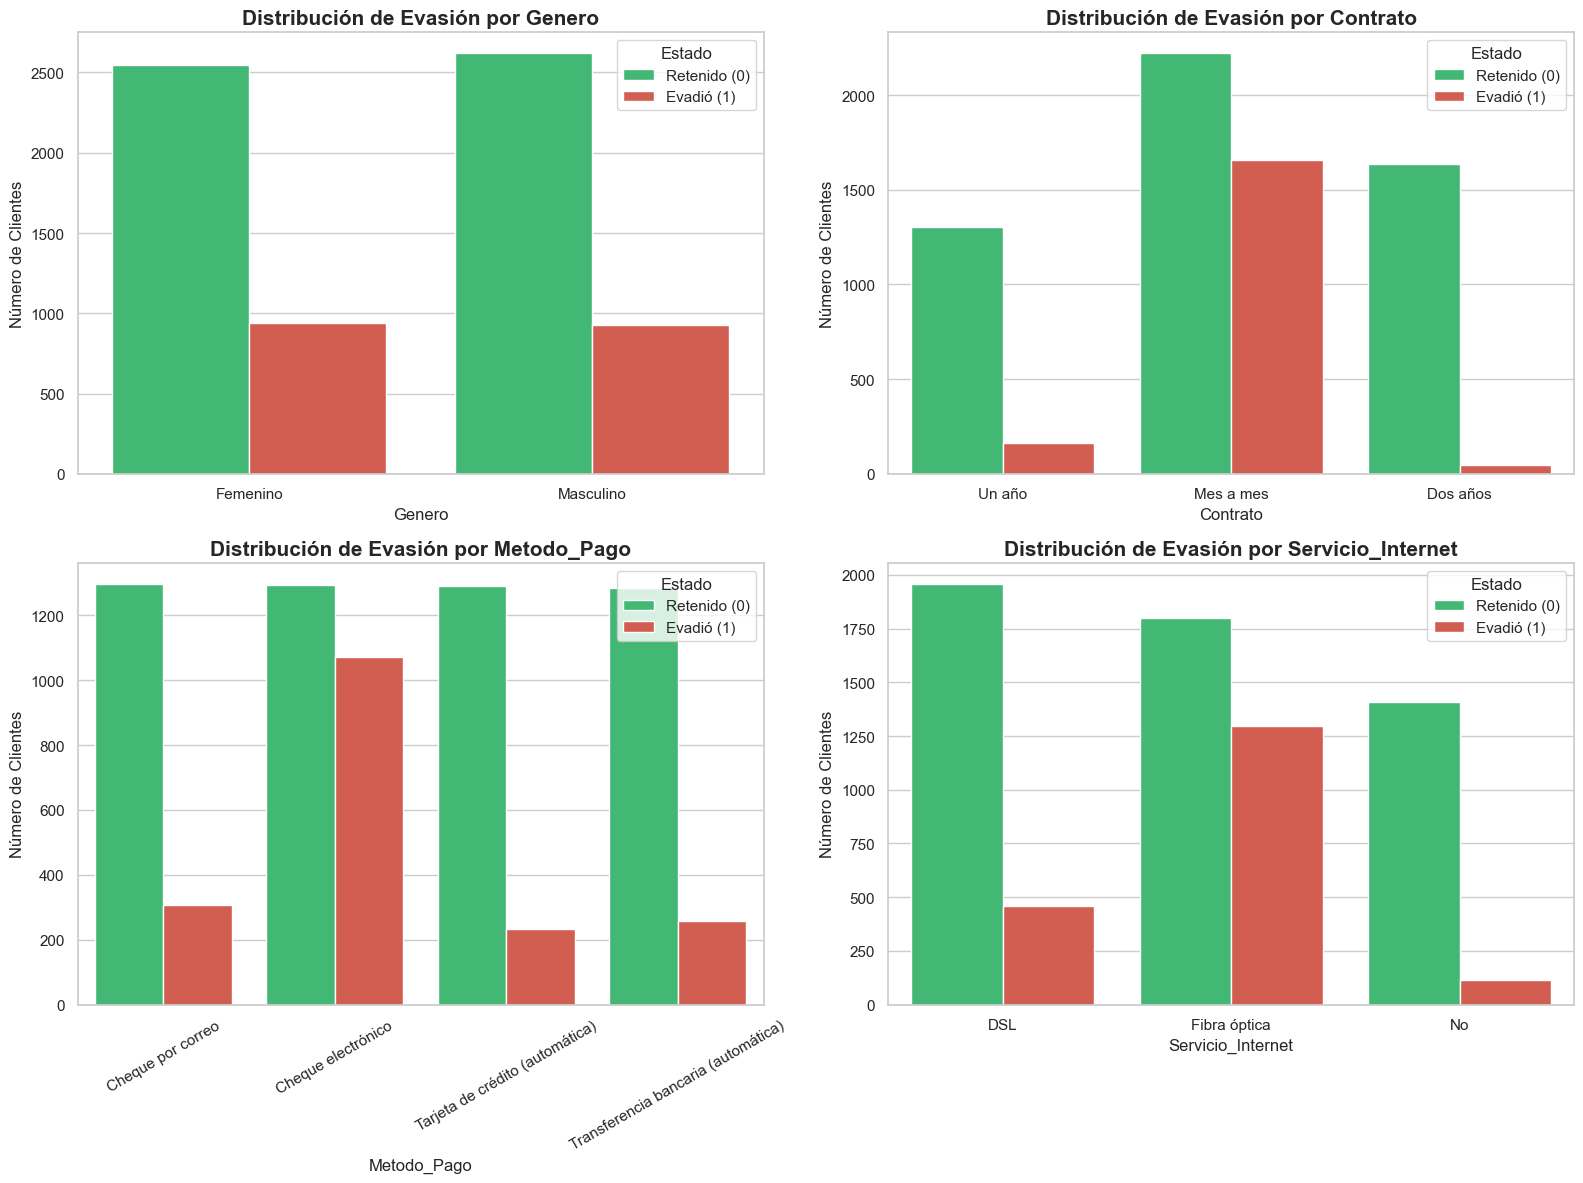

In [23]:
# Lista de variables categóricas clave
variables_analisis = ['Genero', 'Contrato', 'Metodo_Pago', 'Servicio_Internet']

# Creamos la figura con 2 filas y 2 columnas
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(variables_analisis):
    # Gráfico de barras agrupado por la variable 'Evasion'
    sns.countplot(data=df_normalizado, x=col, hue='Evasion',
                  palette=['#2ecc71', '#e74c3c'], ax=axes[i])

    # Personalización de títulos y etiquetas
    axes[i].set_title(f'Distribución de Evasión por {col}', fontsize=15, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Número de Clientes', fontsize=12)
    axes[i].legend(title='Estado', labels=['Retenido (0)', 'Evadió (1)'])

    # Rotar etiquetas si es el Método de Pago para que no se amontonen
    if col == 'Metodo_Pago':
        axes[i].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

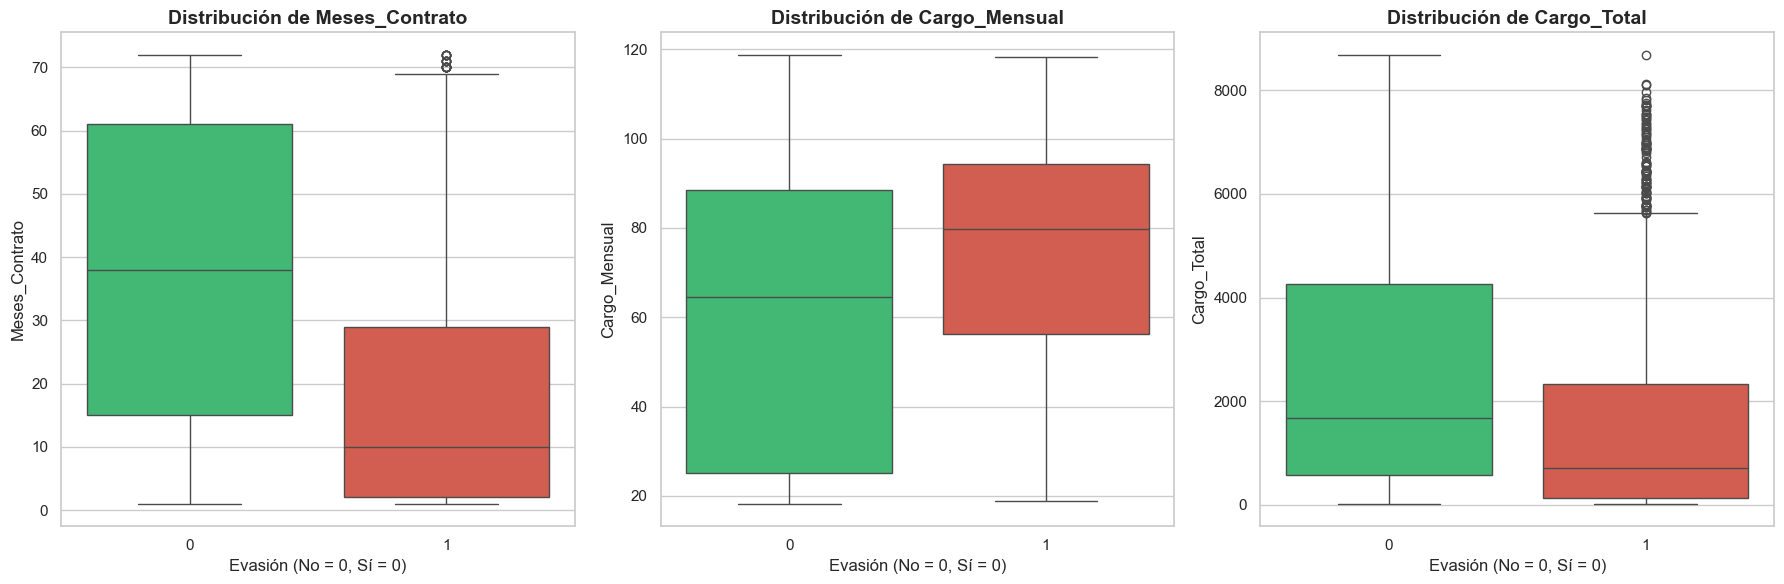

In [24]:
# Variables numéricas clave de Telecom X
variables_numericas = ['Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total']

# Creamos la figura
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, col in enumerate(variables_numericas):
    # La corrección: agregamos hue='Evasion' y legend=False
    sns.boxplot(data=df_normalizado,
                x='Evasion',
                y=col,
                hue='Evasion', # Ahora el color sabe que depende de la Evasión
                palette=['#2ecc71', '#e74c3c'],
                legend=False,   # Quitamos la leyenda para que no estorbe
                ax=axes[i])

    # Personalización
    axes[i].set_title(f'Distribución de {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Evasión (No = 0, Sí = 0)')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

# 📄Informe final

# Análisis de Evasión de Clientes (Churn) en Telecom X

## 🔹 Introducción
El presente informe detalla el análisis realizado sobre la base de datos de clientes de **Telecom X**. El objetivo principal de este proyecto es identificar los factores clave que impulsan la **evasión de clientes (Churn)**, una métrica crítica que impacta directamente en los ingresos de la compañía. Al comprender el comportamiento y las características de los usuarios que deciden cancelar su servicio, Telecom X podrá diseñar estrategias de retención más efectivas y proactivas.

## 🔹 Limpieza y Tratamiento de Datos
Para garantizar la calidad del análisis, los datos crudos (originalmente en formato JSON anidado) pasaron por un riguroso proceso de normalización (ETL):
1. **Desanidación:** Se extrajeron variables clave de estructuras complejas (ej. demografía, servicios, cuenta).
2. **Transformación de Tipos:** Se corrigió la columna de `Cargo_Total` (Charges.Total), la cual venía como texto con espacios vacíos, convirtiéndola a un formato numérico flotante para permitir cálculos matemáticos.
3. **Manejo de Nulos:** Se eliminaron las filas correspondientes a clientes recién ingresados que no tenían un historial de facturación consolidado.
4. **Estandarización:** Se tradujeron todas las columnas al español y se mapearon variables categóricas de "Yes/No" a formatos binarios (1 y 0) para facilitar su visualización y futuro modelado predictivo.

## 🔹 Análisis Exploratorio de Datos (EDA)
A través de la visualización de datos, exploramos la distribución de la base de usuarios y su relación con la tasa de evasión:
* **Diagnóstico General:** Se identificó una tasa de evasión del **26.6%**, lo que significa que más de 1 de cada 4 clientes abandona la empresa.
* **Análisis Categórico:**
  * Los clientes con un **contrato "Mes a mes"** representan la inmensa mayoría de las cancelaciones en comparación con los contratos anuales.
  * Los usuarios del servicio de **Fibra Óptica** muestran una mayor proporción de fuga que los de DSL.
  * El método de pago mediante **Cheque Electrónico** está fuertemente asociado a la cancelación del servicio.
* **Análisis Numérico:**
  * **Meses de Contrato (Tenure):** Los clientes que cancelan tienen una antigüedad significativamente menor, concentrándose la fuga en los primeros meses de servicio.
  * **Cargos Mensuales:** La mediana del pago mensual es visiblemente más alta entre los clientes que deciden irse, lo que sugiere una alta sensibilidad al precio.

## 🔹 Conclusiones e Insights
El análisis revela que la evasión en Telecom X no es un evento aleatorio, sino que sigue un patrón claro. La **"huella digital" del cliente con mayor riesgo de fuga** corresponde a: un usuario en sus primeros meses de servicio, bajo un contrato de mes a mes, que utiliza fibra óptica, paga mediante cheque electrónico y enfrenta facturas mensuales por encima del promedio.

El problema principal de Telecom X radica en la **fidelización temprana** y la **percepción de valor**. La barrera de salida para los contratos mensuales es inexistente, y si esto se combina con un servicio premium (fibra) de alto costo, el usuario no duda en cambiar de proveedor ante la menor fricción.

## 🔹 Recomendaciones Estratégicas
Basado en los datos analizados, se sugieren las siguientes acciones para Telecom X:
1. **Incentivar Contratos a Largo Plazo:** Ofrecer descuentos agresivos o beneficios extra (como meses gratis de streaming) a los usuarios que decidan migrar de un esquema "Mes a mes" a un contrato de 1 o 2 años.
2. **Revisión de Precios y Calidad en Fibra Óptica:** Investigar si la fuga en fibra óptica se debe a inestabilidad técnica o precios fuera de mercado. Se sugiere lanzar un paquete de "entrada" a la fibra óptica con un costo mensual más competitivo.
3. **Automatización de Pagos:** Diseñar campañas para que los usuarios de "Cheque Electrónico" domicilien sus pagos a una tarjeta de crédito o cuenta bancaria, ofreciendo un pequeño descuento mensual por hacerlo. Esto reduce la decisión manual de pagar (y potencialmente cancelar) mes a mes.
4. **Programa de Onboarding (Primeros 6 meses):** Dado que los clientes se van rápido (baja antigüedad), crear un programa de atención especial y seguimiento técnico durante los primeros 6 meses de vida del cliente para asegurar su satisfacción y cruzar el umbral crítico de riesgo.

# ¡EXTRA!

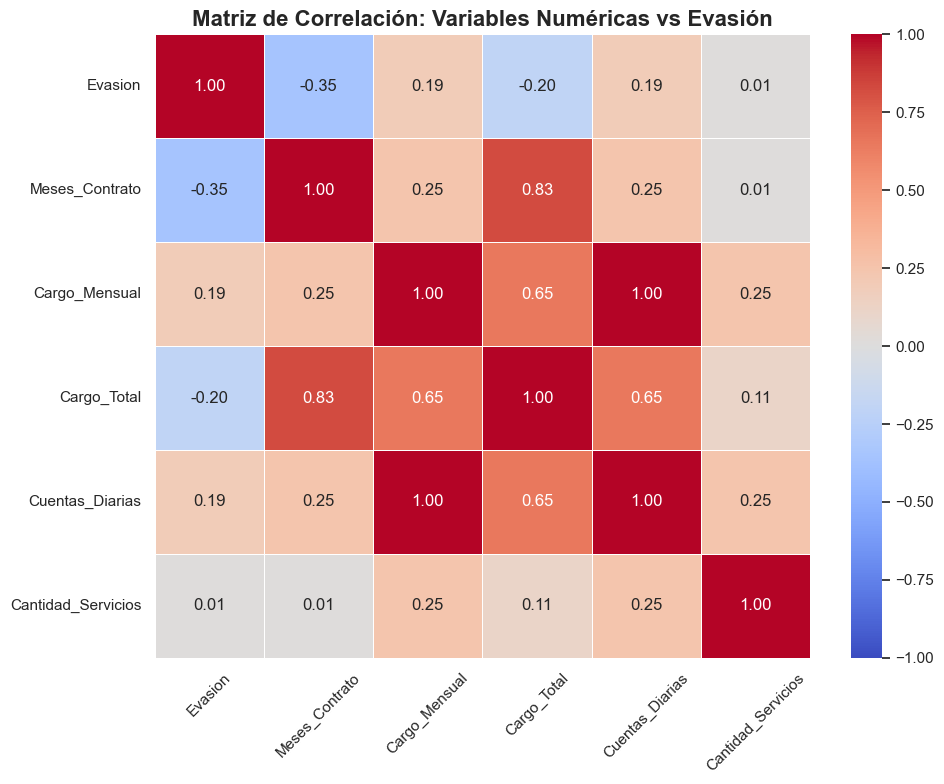

In [25]:
# 1. Crear la variable "Cantidad_Servicios"
# Lista de servicios que el cliente puede o no tener
servicios = ['Servicio_Telefonico', 'Seguridad_Online', 'Respaldo_Online',
             'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas']

# Convertimos temporalmente los "Yes" a 1 y los "No" o "No internet service" a 0 para poder sumarlos
df_servicios = df_normalizado[servicios].replace({'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0})

# Sumamos los servicios por cada fila
df_normalizado['Cantidad_Servicios'] = df_servicios.apply(pd.to_numeric, errors='coerce').sum(axis=1)

# 3. Seleccionar las variables numéricas para correlacionar
columnas_corr = ['Evasion', 'Meses_Contrato', 'Cargo_Mensual', 'Cargo_Total',
                 'Cuentas_Diarias', 'Cantidad_Servicios']

# Calculamos la matriz de correlación de Pearson
matriz_correlacion = df_normalizado[columnas_corr].corr()

# 4. Visualizar la Matriz de Correlación (Heatmap)
plt.figure(figsize=(10, 8))
# Usamos 'coolwarm' donde rojo es correlación positiva (se mueven juntas) y azul es negativa (inversas)
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f",
            linewidths=0.5, vmin=-1, vmax=1)

plt.title('Matriz de Correlación: Variables Numéricas vs Evasión', fontsize=16, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 🔹 Análisis de Correlación: Descubriendo Relaciones Ocultas

Para ir un paso más allá en nuestro Análisis Exploratorio, evaluamos cómo se relacionan matemáticamente nuestras variables numéricas con la **Evasión (Churn)** utilizando una Matriz de Correlación (Heatmap).

Utilizamos el coeficiente de correlación de Pearson, que nos devuelve un valor entre -1 y 1 para cada par de variables:
* **Correlación Positiva (hacia 1, tonos cálidos/rojos):** Si una variable sube, la otra también.
* **Correlación Negativa (hacia -1, tonos fríos/azules):** Si una variable sube, la otra baja (relación inversa).
* **Cercano a 0:** No hay relación lineal aparente.

#### 📊 Principales Hallazgos (Insights):

1. **La Sensibilidad al Precio (Cuentas_Diarias / Cargo_Mensual vs. Evasión):**
   * **Relación:** Positiva.
   * **Interpretación:** A medida que la cuenta diaria o el cargo mensual del cliente aumenta, también crece la probabilidad de que cancele el servicio. Esto confirma matemáticamente que existe una fuerte sensibilidad al precio en la base de usuarios.

2. **El "Efecto Ecosistema" (Cantidad_Servicios vs. Evasión):**
   * **Relación:** Negativa.
   * **Interpretación:** Los clientes que tienen múltiples servicios contratados simultáneamente (ej. Teléfono + Seguridad Online + TV) tienen *menor* tendencia a la fuga. Estar inmerso en múltiples soluciones de la empresa crea una "barrera de salida" por conveniencia; es más difícil cambiar de proveedor cuando tienes 4 servicios integrados que cuando solo tienes 1.

3. **El Escudo del Tiempo (Meses_Contrato vs. Evasión):**
   * **Relación:** Negativa (la más fuerte del modelo).
   * **Interpretación:** A mayor antigüedad del cliente, el riesgo de cancelación se desploma drásticamente. Esto reitera que el verdadero desafío de retención de Telecom X ocurre en las etapas tempranas del ciclo de vida del cliente.

#### 💡 Valor Estratégico para Modelado Predictivo:
Estos índices de correlación son el cimiento para la futura creación de modelos de Machine Learning. Nos indican estratégicamente que para reducir el Churn, la empresa debe enfocarse en **estrategias de venta cruzada (cross-selling)**: incentivar a los usuarios nuevos a adoptar más servicios complementarios para asegurar su permanencia durante los primeros meses críticos.